In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
import random
from collections import deque
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F

C_DQN  = "dodgerblue"
C_HEUR = "darkorange"

pi = np.pi

import noisy_nstep_d_dqn as dqn
import hex_world_exploring_starts as hex_world
import oracle

from sweep_fn_3 import *
from plot_fn_3 import *

In [ ]:
def sim_instance(
        seed=None,
        model_type="vanilla_DQN",
        n_step = 10,
        sigma_0= 0.5,
        curriculum_mode="disabled",
        comfort_surface="exponential",
        random_start="targeted",
        novelty_rewards=True,
        beta=0.05,
        sim_len=500000,
        env_kwargs=None,
        hmax = 3,
        smax = 3,
        memory_len=10,
        replay_archive_len=5000,
        n_hidden=64,
        over_w = 0.02,
        under_w = 0.5,
        epsilon_start=0.3,
        gamma=0.99,
        alpha=0.01,
        death_penalty_k=0.5,
        batch_size=512,
        update_ticks=500,
        replay_warmup=500,
        learn_every=20,
        eval_len=20000,
        check_eval_states=False,
        debug_diet_cause = False,
        debug_n_step=False
):

    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
        torch.manual_seed(seed)

    EB = sim_len - eval_len

    if env_kwargs is None:
        env_kwargs = dict(radius=3)
        
    if debug_diet_cause:
        print("DIET DEBUG ON")

    if check_eval_states:
        print("CHECK EVAL STATES ON")

    if debug_n_step:
        print("N STEP DEBUG ON")

    register = {
        "vanilla_DQN" : {
            "fn_make_model" : dqn.vanilla_make_model,
            "fn_make_target" : dqn.vanilla_make_target,
            "fn_sync_target" : dqn.vanilla_sync_target,
            "fn_learn_step" : dqn.vanilla_learn_step,
            "fn_select_action" : dqn.vanilla_select_action
        },

        "double_DQN" : {
            "fn_make_model" : dqn.vanilla_make_model,
            "fn_make_target" : dqn.vanilla_make_target,
            "fn_sync_target" : dqn.vanilla_sync_target,
            "fn_learn_step" : dqn.double_learn_step,
            "fn_select_action" : dqn.vanilla_select_action
        },

        "oracle": {
            "fn_make_model": oracle.make_model,
            "fn_make_target": oracle.make_target,
            "fn_sync_target": oracle.sync_target,
            "fn_learn_step": oracle.learn_step,
            "fn_select_action": oracle.select_action,
        },

        "noisy_DQN": {
            "fn_make_model": dqn.noisy_make_model,
            "fn_make_target": dqn.noisy_make_target,
            "fn_sync_target": dqn.noisy_sync_target,
            "fn_learn_step": dqn.noisy_learn_step,
            "fn_select_action": dqn.vanilla_select_action,
        },
    }

    curriculum = {
        "disabled" : [
            {},
        ],

        "coordinate" : [
            {"water_coord": (-2, 0), "food_coord": (0, 2)},
            {"water_coord": (-3, 0), "food_coord": (0, 3)},
            {"water_coord": (-4, 0), "food_coord": (0, 4)},
            {"water_coord": (-5, 0), "food_coord": (0, 5)},
        ]
    }

    phase_i = -99
    phase_edges = np.linspace(0, EB, len(curriculum[curriculum_mode]) + 1, dtype=int)[1:-1]
    base_env_kwargs = env_kwargs.copy()

    def curriculum_phase(t, curr_env, phase_index):
        new_phase_i = int(np.digitize(t, phase_edges))

        need_build = curr_env is None
        need_phase_change = (new_phase_i != phase_index and curriculum_mode != "disabled")

        if need_build or need_phase_change:
            phase = curriculum[curriculum_mode][new_phase_i]

            current_env_kwargs = base_env_kwargs | phase
            new_env = hex_world.HexWorld(**current_env_kwargs)

            return new_env, new_phase_i, (not need_build)

        return curr_env, phase_index, False

    env, phase_i, _ = curriculum_phase(t=0, curr_env=None, phase_index=phase_i)

    actual_water_coord = tuple(env.water_coord)
    actual_food_coord = tuple(env.food_coord)

    coord_to_idx = {tuple(c): i for i, c in enumerate(env.coords)}
    novelty_N = np.zeros(len(env.coords), dtype=np.int64)

    r_model = register[model_type]

    fn_make_model = r_model["fn_make_model"]
    fn_make_target = r_model["fn_make_target"]
    fn_sync_target = r_model["fn_sync_target"]
    fn_learn_step = r_model["fn_learn_step"]
    fn_select_action = r_model["fn_select_action"]

    if model_type == "oracle":
        oracle.configure(
            water_coord=actual_water_coord,
            food_coord=actual_food_coord,
            fill_h=1.7,
            fill_s=1.7,
        )

    eps_start = epsilon_start
    eps_end = 0.05
    full_phase_edges = np.concatenate([[0], phase_edges, [EB]])
    eps_decay_frac = 0.7
    phase_start_t = 0
    cur_phase_decay_ticks = int(eps_decay_frac * (full_phase_edges[phase_i + 1] - full_phase_edges[phase_i]))

    ideal_h = 1
    ideal_s = 1
    day_length = 50 # ticks

    h = ideal_h
    s = ideal_s

    drink_amount = 0.15
    eat_amount = 0.3

    action_effects = np.array([
        [0.0, 0.0, None],   # 0 wait
        [1.0, 0.0, None],   # 1 drink full
        [0.5, 0.0, None],   # 2 drink half
        [0.25, 0.0, None],  # 3 drink quarter
        [0.0, 1.0, None],   # 4 eat full
        [0.0, 0.5, None],   # 5 eat half
        [0.0, 0.25, None],  # 6 eat quarter
        [0.0, 0.0, 0],      # 7 move E
        [0.0, 0.0, 1],      # 8 move NE
        [0.0, 0.0, 2],      # 9 move NW
        [0.0, 0.0, 3],      # 10 move W
        [0.0, 0.0, 4],      # 11 move SW
        [0.0, 0.0, 5],      # 12 move SE
    ], dtype=object)

    positions1 = np.arange(1, 8)
    weights1 = (11 - positions1) ** 2
    proportions1 = weights1 / weights1.sum()

    positions2 = np.arange(1, 11)
    ##weights2 = positions2 ** 2
    proportions2 = positions2 / positions2.sum()

    r_que = deque(maxlen=replay_archive_len)
    m_que_d = deque([0] * memory_len, maxlen=memory_len)
    m_que_e = deque([0] * memory_len, maxlen=memory_len)
    m_que_m = deque([-1] * memory_len, maxlen=memory_len) # -1 means no movement action remembered
    n_step_que = deque(maxlen=n_step)
    a_que = deque(maxlen=11)

    action_names = [
    "wait",
    "drink_full", "drink_half", "drink_quarter",
    "eat_full", "eat_half", "eat_quarter",
    "move_E", "move_NE", "move_NW", "move_W", "move_SW", "move_SE",
    ]

    debug_food_eval = True
    debug_food_limit = 80
    debug_food_count = 0

    def hex_dist(a, b):
        aq, ar = a
        bq, br = b
        return max(abs(aq - bq), abs(ar - br), abs((-aq - ar) - (-bq - br)))

    death_penalty = -death_penalty_k / (1 - gamma)

    N_ACT = len(action_effects)

    # state = q, r, cube_s, hydration, satiation, brightness, drink memory, eat memory, move memory
    N_INPUT = 6 + memory_len * 3

    carry_x = ()
    carry_act = 0

    if model_type == "noisy_DQN":
        if epsilon_start != 0:
            print(f"eps is {epsilon_start}, and noisy nets is active, but eps will remain {epsilon_start}")
        model, optimiser = fn_make_model(N_INPUT, n_hidden, N_ACT, lr=alpha, sigma_0=sigma_0)
        
    else:
        model, optimiser = fn_make_model(N_INPUT, n_hidden, N_ACT, lr=alpha)    
        
    target = fn_make_target(model)

    if model_type == "oracle":
        model.set_context(
            coord=tuple(env.coord),
            hydration=h,
            satiation=s,
        )

    lifetime_stats = [[], [], [], [], [], [], [], [], [], []]
    death_events = []
    sigma_w_mean = []

    eval_zeros = [0] * memory_len
    eval_move_zeros = [-1] * memory_len
    eval_states = {
        "thirsty":   np.array([0, 0, 0, 0.2, 1.0, 0.5, *eval_zeros, *eval_zeros, *eval_move_zeros], dtype=np.float32),
        "hungry":    np.array([0, 0, 0, 1.0, 0.2, 0.5, *eval_zeros, *eval_zeros, *eval_move_zeros], dtype=np.float32),
        "desperate": np.array([0, 0, 0, 0.2, 0.2, 0.5, *eval_zeros, *eval_zeros, *eval_move_zeros], dtype=np.float32),
        "overfull":  np.array([0, 0, 0, 1.5, 1.5, 0.5, *eval_zeros, *eval_zeros, *eval_move_zeros], dtype=np.float32),
    }

    def get_brightness(time, day_len=100):
        a = 0.5
        b = 0.3
        c = (2*pi) / day_len

        brightness = a + b*np.sin(c*time)
        brightness += np.random.normal(0, 0.05)
        return min(1, max(0, brightness))
    
    world_size = env.radius
    hydration_decay_scaling = 0.05 + 1.45 / ((1 + 1.0426*(world_size-1))**0.7122)
    satiation_decay_scaling = 0.85 * hydration_decay_scaling

    #print(world_size, hydration_decay_scaling, satiation_decay_scaling)

    def decay_hydration(hydration, satiation, brightness):
        decay = max(0, (0.15*brightness) - (0.03*satiation))
        decay += np.random.normal(0.05, 0.03)
        return hydration - decay * hydration_decay_scaling

    def decay_satiation(satiation, hydration, brightness):
        decay = max(0, ((0.05 - 0.05*brightness) + (0.04 - 0.04*hydration) + 0.1*(ideal_h - hydration)))        
        decay += np.random.normal(0.01, 0.005)
        return satiation - decay * satiation_decay_scaling

    def the_meaning_of_life_exp(hydration, satiation):

        h_over = max(0, hydration - ideal_h)
        h_under = min(0, hydration - ideal_h)

        s_over = max(0, satiation - ideal_s)
        s_under = min(0, satiation - ideal_s)

        d2 = (
            under_w * h_under**2 +
            over_w  * h_over**2 +
            under_w * s_under**2 +
            over_w  * s_over**2
        )

        return 2 * np.exp(-3 * d2) - 1
    
    def the_meaning_of_life_quad(hydration, satiation):

        h_over = max(0, hydration - ideal_h)
        h_under = min(0, hydration - ideal_h)

        s_over = max(0, satiation - ideal_s)
        s_under = min(0, satiation - ideal_s)

        d2 = (
            under_w * h_under**2 +
            over_w  * h_over**2 +
            under_w * s_under**2 +
            over_w  * s_over**2
        )

        return 1 - d2
    
    if comfort_surface == "quadratic":
        the_meaning_of_life = the_meaning_of_life_quad
    elif comfort_surface == "exponential":
        the_meaning_of_life = the_meaning_of_life_exp

    def sample_box(h_lo, h_hi, s_lo, s_hi):
        return np.random.uniform(h_lo, h_hi), np.random.uniform(s_lo, s_hi)

    def coord_at_dist(anchor, d):
        ring = [c for c in env.coords if hex_dist(c, anchor) == d]
        if not ring:
            ring = [c for c in env.coords if hex_dist(c, anchor) <= max(1, d)]
        return ring[np.random.randint(len(ring))]

    def sample_uniform_start():
        while True:
            angle = np.random.uniform(0, 2*np.pi)
            rad = np.sqrt(np.random.uniform(0.1**2, 2.9**2))
            nh = ideal_h + rad*np.cos(angle)
            ns = ideal_s + rad*np.sin(angle)
            if (0.05 < nh < hmax) and (0.05 < ns < smax) and not (nh < 0.35 and ns < 0.35):
                return float(nh), float(ns), tuple(env.coords[np.random.randint(len(env.coords))])

    targeted_names = ["hungry_food", "hungry_water", "thirsty_water", "thirsty_food", "overfull", "both_low"]
    targeted_weights = np.array([3, 3, 1, 1, 1, 1], dtype=float)
    targeted_weights /= targeted_weights.sum()

    def sample_targeted_start(reach):
        pick = targeted_names[np.random.choice(len(targeted_names), p=targeted_weights)]

        if pick == "hungry_food":
            h0, s0 = sample_box(0.9, 1.3, 0.15, 0.45); anchor = env.food_coord
        elif pick == "hungry_water":
            h0, s0 = sample_box(0.9, 1.3, 0.15, 0.45); anchor = env.water_coord
        elif pick == "thirsty_water":
            h0, s0 = sample_box(0.15, 0.45, 0.9, 1.3); anchor = env.water_coord
        elif pick == "thirsty_food":
            h0, s0 = sample_box(0.15, 0.45, 0.9, 1.3); anchor = env.food_coord
        elif pick == "overfull":
            h0, s0 = sample_box(1.3, 1.7, 1.3, 1.7); anchor = None
        else:
            h0, s0 = sample_box(0.4, 0.7, 0.4, 0.7); anchor = None

        if anchor is None:
            coord = env.coords[np.random.randint(len(env.coords))]
        else:
            coord = coord_at_dist(anchor, np.random.randint(0, reach + 1))

        return float(h0), float(s0), tuple(coord)

    def reach_at(t):
        return 1 + int((t / EB) * env.radius)

    def targeted_prob(t):
        end = 0.8 * EB
        return 0.0 if t >= end else 0.8 * (1 - t / end)

####################################################################################################################  
    for t in range(sim_len):#########################} SIM LOOP {###################################################
        if t == EB:#################################################################################################
            model.eval()

        b = get_brightness(t, day_length)
        h = decay_hydration(h, s, b)
        s = decay_satiation(s, h, b)

        env, phase_i, new_phase = curriculum_phase(t=t, curr_env=env, phase_index=phase_i)

        if new_phase:
            env.reset_position()

            n_step_que.clear()

            r_que.clear()

            m_que_d.clear()
            m_que_e.clear()
            m_que_m.clear()

            m_que_d.extend([0] * memory_len)
            m_que_e.extend([0] * memory_len)
            m_que_m.extend([-1] * memory_len)

            a_que.clear()
            a_que.extend([0] * memory_len)

            fn_sync_target(target, model)

            phase_start_t = t
            cur_phase_decay_ticks = int(eps_decay_frac * (full_phase_edges[phase_i + 1] - full_phase_edges[phase_i]))

            new_phase = False

        for age, act in enumerate(a_que):
            drink_choice, eat_choice, move_choice = action_effects[act]

            if age == 0:
                env.apply_action_movement(act) # movement is handled by the physical world now

            if age < len(proportions1):
                h += drink_amount * drink_choice * proportions1[age] * (0.8 + 0.3*s) 

            if age < len(proportions2):
                s += eat_amount * eat_choice * proportions2[age]

        h = min(hmax, max(0, h))
        s = min(smax, max(0, s))

        cur_comfort = the_meaning_of_life(h, s)
        cur_dead = int((h <= 0.05) or (s <= 0.05))

        novelty_r = 0
        if novelty_rewards and t < EB: 
            novelty_idx = coord_to_idx[tuple(env.coord)]
            novelty_r = beta / np.sqrt(novelty_N[novelty_idx] + 1)
            novelty_N[novelty_idx] += 1

        cur_reward = cur_comfort + novelty_r + death_penalty*cur_dead

        if cur_dead and t != 0:
            if h <= 0.05 and s <= 0.05:
                death_cause = "both"
            elif h <= 0.05:
                death_cause = "hydration"
            else:
                death_cause = "satiation"

            death_events.append({
                "t": t,
                "cause": death_cause,
                "h": h,
                "s": s,
            })

        cur_x = env.make_state(h, s, b, m_que_d, m_que_e, m_que_m)
        cur_mask = env.get_action_mask()

        if t != 0 and t < EB and model_type != "oracle": # dont learn if we dont know anything

            n_step_que.append([carry_x, carry_act, cur_reward, cur_x, bool(cur_dead), cur_mask])

            while n_step_que:

                state_0 = n_step_que[0].copy()
                states_added = 0
                state_0[2] = 0
                completed_state = False

                for i, transition in enumerate(n_step_que.copy()):
                    state_0[2] += transition[2] * gamma**i
                    for n in [3, 4, 5]:
                        state_0[n] = transition[n]
                    states_added += 1

                    if debug_n_step and state_0[4]:
                        print(f"DEATH FLUSH t={t} n={states_added} q_left={len(n_step_que)}")

                    completed_state = (states_added == n_step) or (transition[4])
                    if completed_state:
                        n_step_que.popleft()
                        break

                if completed_state:
                    r_que.append(tuple(state_0 + [states_added]))
                    if debug_n_step:
                        print(
                            f"EMIT t={t} n={states_added} R={state_0[2]:.3f} "
                            f"done={state_0[4]} q_left={len(n_step_que)}"
                        )
                else:
                    break

            if t % learn_every == 0 and len(r_que) >= replay_warmup:
                if t % (update_ticks * learn_every) == 0:
                    fn_sync_target(target, model)

                batch = random.sample(r_que, min(batch_size, len(r_que)))

                fn_learn_step(model, target, optimiser, batch, gamma)

        
        log_coord = tuple(env.coord)
        log_h = h
        log_s = s
        log_m_d = list(m_que_d)
        log_m_e = list(m_que_e)
        log_m_m = list(m_que_m)

        if debug_diet_cause and t >= EB:
            food_coord_tuple = tuple(env_kwargs.get("food_coord", (1, 0)))
            dist_to_food_log = hex_dist(tuple(env.coord), food_coord_tuple)

            if dist_to_food_log <= 1:
                print("/nPRE-RESET FOOD DEBUG")
                print("t:", t, "eval_tick:", t - EB)
                print("coord:", tuple(env.coord), "food:", food_coord_tuple, "dist:", dist_to_food_log)
                print("h, s:", round(float(h), 4), round(float(s), 4))
                print("cur_dead:", cur_dead, "cur_reward:", round(float(cur_reward), 4))
                print("mask:", [(i, action_names[i]) for i in np.flatnonzero(cur_mask)])
                
        if cur_dead:
            use_targeted = (
                random_start == "targeted"
                and t < EB
                and np.random.uniform() < targeted_prob(t)
            )

            if use_targeted:
                h, s, new_coord = sample_targeted_start(reach_at(t))
            else:
                h, s, new_coord = sample_uniform_start()

            env.reset_position(coord=new_coord)

            a_que.clear()
            m_que_d.clear()
            m_que_e.clear()
            m_que_m.clear()

            m_que_d.extend([0] * memory_len)
            m_que_e.extend([0] * memory_len)
            m_que_m.extend([-1] * memory_len)

            cur_x = env.make_state(h, s, b, m_que_d, m_que_e, m_que_m)
            cur_mask = env.get_action_mask()

        if t < EB:
            frac = min(1.0, (t - phase_start_t) / cur_phase_decay_ticks)
            epsilon_t = eps_start + frac * (eps_end - eps_start)
        else:
            epsilon_t = 0.0
            
        # DEBUG: inspect what the greedy policy wants to do near food during eval
        if debug_food_eval and t >= EB and debug_food_count < debug_food_limit and debug_diet_cause:
            decision_coord = tuple(env.coord)
            food_coord_tuple = tuple(env_kwargs.get("food_coord", (1, 0)))

            # on food or adjacent to food
            if hex_dist(decision_coord, food_coord_tuple) <= 1:
                with torch.no_grad():
                    x_dbg = torch.as_tensor(cur_x, dtype=torch.float32)
                    q_dbg = model(x_dbg).detach().cpu().numpy()

                mask_dbg = np.asarray(cur_mask, dtype=bool)
                q_masked_dbg = q_dbg.copy()
                q_masked_dbg[~mask_dbg] = -1e9

                chosen_dbg = int(np.argmax(q_masked_dbg))
                valid_actions_dbg = np.flatnonzero(mask_dbg)

                top_actions = sorted(
                    [(i, action_names[i], float(q_masked_dbg[i])) for i in range(len(q_masked_dbg))],
                    key=lambda z: z[2],
                    reverse=True
                )[:6]

                print("/nFOOD DEBUG")
                print("t:", t, "eval_tick:", t - EB)
                print("coord:", decision_coord, "food:", food_coord_tuple, "dist:", hex_dist(decision_coord, food_coord_tuple))
                print("h, s:", round(float(h), 4), round(float(s), 4))
                print("valid actions:", [(int(i), action_names[int(i)]) for i in valid_actions_dbg])
                print("chosen greedy:", chosen_dbg, action_names[chosen_dbg])
                print("eat valid?:", {action_names[i]: bool(mask_dbg[i]) for i in [4, 5, 6]})
                print("eat Qs:", {action_names[i]: round(float(q_dbg[i]), 4) for i in [4, 5, 6]})
                print("top masked Qs:", [(i, name, round(q, 4)) for i, name, q in top_actions])

                debug_food_count += 1

        if model_type == "oracle":
            model.set_context(
                coord=tuple(env.coord),
                hydration=h,
                satiation=s,
            )
            action = fn_select_action(model, cur_x, cur_mask)

        else:
            if np.random.uniform(0, 1) < epsilon_t:
                valid_actions = np.flatnonzero(cur_mask)
                action = int(np.random.choice(valid_actions))
            else:
                action = fn_select_action(model, cur_x, cur_mask)

        a_que.appendleft(action)

        drink_memory, eat_memory, move_memory = action_effects[action]

        m_que_d.appendleft(float(drink_memory))
        m_que_e.appendleft(float(eat_memory))
        m_que_m.appendleft(-1 if move_memory is None else int(move_memory))

        carry_x = cur_x
        carry_act = action

        lifetime_stats[0].append(cur_comfort)
        lifetime_stats[1].append(action)
        lifetime_stats[2].append([log_m_d, log_m_e, log_m_m])
        lifetime_stats[3].append(log_h)
        lifetime_stats[4].append(log_s)
        lifetime_stats[5].append(b)
        lifetime_stats[7].append(cur_reward)
        lifetime_stats[8].append(cur_dead)
        lifetime_stats[9].append(log_coord)

        
        if model_type == "noisy_DQN" and t % learn_every == 0 and t < EB:
            sigma_w_mean.append(model.fc2.sigma_w.abs().mean().item())

        if check_eval_states:
            cur_eval_state_q = []
            for name, state in eval_states.items():
                q = model(torch.as_tensor(state, dtype=torch.float32))
                cur_eval_state_q.append(q)
            lifetime_stats[6].append(cur_eval_state_q)

    lifetime_comfort = np.array(lifetime_stats[0])
    lifetime_action = np.array(lifetime_stats[1])
    lifetime_memory = np.array(lifetime_stats[2])
    lifetime_coordinates = np.array(lifetime_stats[9])
    lifetime_hydration = np.array(lifetime_stats[3])
    lifetime_satiation = np.array(lifetime_stats[4])
    lifetime_brightness = np.array(lifetime_stats[5])

    coord_eval = lifetime_coordinates[EB:]

    water_coord = np.array(env.water_coord)
    food_coord = np.array(env.food_coord)

    ticks_at_water_eval = np.all(coord_eval == water_coord, axis=1).sum()
    ticks_at_food_eval = np.all(coord_eval == food_coord, axis=1).sum()

    lifetime_reward = np.array(lifetime_stats[7])
    death_T = np.array(lifetime_stats[8])

    return {
        "comfort_T" :    lifetime_comfort,
        "action_T" :     lifetime_action,
        "memory_T" :     lifetime_memory,
        "coordinates_T": lifetime_coordinates,
        "hydration_T" :  lifetime_hydration,
        "satiation_T" :  lifetime_satiation,
        "brightness_T" : lifetime_brightness,

        "comfort_train" :    lifetime_comfort[ :EB],
        "action_train" :     lifetime_action[ :EB],
        "memory_train" :     lifetime_memory[ :EB],
        "coordinates_train": lifetime_coordinates[ :EB],
        "hydration_train" :  lifetime_hydration[ :EB],
        "satiation_train" :  lifetime_satiation[ :EB],
        "brightness_train" : lifetime_brightness[ :EB],

        "comfort_eval" :    lifetime_comfort[EB: ],
        "action_eval" :     lifetime_action[EB: ],
        "memory_eval" :     lifetime_memory[EB: ],
        "coordinates_eval": coord_eval,
        "hydration_eval" :  lifetime_hydration[EB: ],
        "satiation_eval" :  lifetime_satiation[EB: ],
        "brightness_eval" : lifetime_brightness[EB: ],

        "mean_comfort" :   lifetime_comfort[EB: ].mean(),
        "min_comfort" :    lifetime_comfort[EB: ].min(),
        "std_comfort" :    lifetime_comfort[EB: ].std(),
        "mean_hydration" : lifetime_hydration[EB: ].mean(),
        "mean_satiation" : lifetime_satiation[EB: ].mean(),

        "ticks_at_water_eval" :  ticks_at_water_eval,
        "ticks_at_food_eval" :   ticks_at_food_eval,

        "reward_T": lifetime_reward,
        "reward_train": lifetime_reward[:EB],
        "reward_eval": lifetime_reward[EB:],
        "mean_reward": lifetime_reward[EB:].mean(),
        "min_reward": lifetime_reward[EB:].min(),
        "max_reward": lifetime_reward[EB:].max(),
        "std_reward": lifetime_reward[EB:].std(),

        "death_T" : death_T,
        "death_events": death_events,
        "death_count" : death_T.sum(),
        "death_rate" : death_T.mean(),
        "death_count_eval": death_T[EB:].sum(),
        "death_rate_eval": death_T[EB:].mean(),

        "sigma_w_mean" : sigma_w_mean
    }

In [ ]:
#region ORACLE SANITY RUN — defaults except model_type
print("Running oracle sanity check...")

run = sim_instance(
    model_type="oracle",
    over_w=0.02,
    env_kwargs={"radius": 5, "water_coord": (-5, 0), "food_coord": (0, 5)},
)

EB = len(run["comfort_train"])

action_names = [
    "wait",
    "drink_full", "drink_half", "drink_quarter",
    "eat_full", "eat_half", "eat_quarter",
    "move_E", "move_NE", "move_NW", "move_W", "move_SW", "move_SE",
]

print("/nRESULTS")
print("mean comfort:", run["mean_comfort"])
print("mean reward:", run["mean_reward"])
print("eval deaths:", run["death_count_eval"])
print("eval death rate:", run["death_rate_eval"])

print("/nSTATE")
print("mean hydration:", run["mean_hydration"])
print("mean satiation:", run["mean_satiation"])
print("min hydration eval:", run["hydration_eval"].min())
print("min satiation eval:", run["satiation_eval"].min())

print("/nRESOURCE VISITS")
print("ticks at water eval:", run["ticks_at_water_eval"])
print("ticks at food eval:", run["ticks_at_food_eval"])

print("/nACTION COUNTS — EVAL")
eval_actions = run["action_eval"]
vals, counts = np.unique(eval_actions, return_counts=True)

for act, count in sorted(zip(vals, counts), key=lambda x: x[1], reverse=True):
    print(f"{int(act):>2} {action_names[int(act)]:<14} {int(count)}")

print("/nDEATH CAUSES — EVAL")
eval_deaths = [d for d in run["death_events"] if d["t"] >= EB]

cause_counts = {}
for d in eval_deaths:
    cause_counts[d["cause"]] = cause_counts.get(d["cause"], 0) + 1

if cause_counts:
    for cause, count in cause_counts.items():
        print(cause, count)
else:
    print("none")

print("/nCOVERAGE")
coords = run["coordinates_eval"]
print("unique tiles eval:", len(set(map(tuple, coords))))
print("first eval coord:", tuple(coords[0]))
print("last eval coord:", tuple(coords[-1]))
#endregion

In [ ]:
#region SWEEP RUN

PROTOTYPE_NAME = "03b_nstep_robust"

EXPERIMENT_NAME = PROTOTYPE_NAME + " " + "FINAL_Noisy_novelty_50krbuf_comfortv3_10step"

N_SEEDS = 100
SEEDS = range(N_SEEDS)

BASE_ENV = dict(
    radius=5,
    water_coord=(-5, 0),
    food_coord=(0, 5),
)

BASE_SIM = dict(
    sim_len=500_000,
    eval_len=20_000,
)

BASE_AGENT = dict(
    model_type="noisy_DQN",
    beta=0.1,
    novelty_rewards=True,
    epsilon_start=0.3,
    replay_archive_len=50000,
    n_step=10,
    over_w=0.02,   
    under_w=0.5,   
)

SWEEP_GRID = {
    "agent.model_type":         ["noisy_DQN"],
    "agent.replay_archive_len": [50000],
    "agent.beta":               [0.1],
    "agent.novelty_rewards":    [True],
    "agent.n_step":             [10],
    "agent.over_w":             [0.02],
    "agent.under_w":            [0.5],
}

configs = make_sweep_configs(
    base_env=BASE_ENV,
    base_sim=BASE_SIM,
    base_agent=BASE_AGENT,
    sweep_grid=SWEEP_GRID,
)

print("experiment:", EXPERIMENT_NAME)
print("configs:", len(configs))
print("seeds:", list(SEEDS))
print("total runs:", len(configs) * len(list(SEEDS)))

print("/nconfig names:")
for cfg in configs:
    print(" ", cfg["name"], cfg["overrides"])

print("/nsim_instance signature:")
print("BASE EFFECTIVE CONFIG:")
print("env:", BASE_ENV)
print("sim:", BASE_SIM)
print("agent:", BASE_AGENT)
print("/nhex_world sanity:")
env_check = hex_world.HexWorld(**BASE_ENV)
print("radius:", env_check.radius)
print("water:", env_check.water_coord)
print("food:", env_check.food_coord)

# --- SMOKE: run every config briefly so broken dispatch surfaces early ---
print("/nSMOKE TEST")

for cfg in configs:
    smoke_config = build_config(
        base_env=cfg["env_kwargs"],
        base_sim={**cfg["sim_kwargs"], "sim_len": 10_000, "eval_len": 1_000},
        base_agent=cfg["agent_kwargs"],
        overrides={},
        name=f"smoke_{cfg['name']}",
    )

    smoke = run_one_config_seed(config=smoke_config, seed=999, train_fn=sim_instance)

    print(
        f"  [{cfg['name']}] "
        f"mean={round(smoke['mean_comfort'], 3)} "
        f"deaths={int(smoke['death_count_eval'])} "
        f"path_eff={smoke['metrics'].get('path_efficiency', float('nan'))}"
    )

RUN_SWEEP = True if input("Run sweep? enter or 1") in ["", "1"] else False

if RUN_SWEEP:
    sweep(
        experiment_name=EXPERIMENT_NAME,
        configs=configs,
        seeds=SEEDS,
        train_fn=sim_instance,
        resume=True,
        PROTOTYPE_NAME=PROTOTYPE_NAME,
    )
else:
    print("/nRUN_SWEEP is False. Change it to True when ready.")

#endregion

In [26]:
import pandas as pd, numpy as np
from pathlib import Path
from statsmodels.stats.proportion import proportion_confint

base = Path("results/sweeps")
DEATH_CAP = 5

frames = []
for csv in base.glob("*/runs_df.csv"):
    d = pd.read_csv(csv)
    d["sweep"] = csv.parent.name          # keep which sweep each row came from
    frames.append(d)
df = pd.concat(frames, ignore_index=True)

pe = pd.to_numeric(df.path_efficiency,      errors="coerce")
pf = pd.to_numeric(df.perfectish_trip_rate, errors="coerce")
dd = pd.to_numeric(df.eval_deaths,          errors="coerce")
df["solved"] = (pe >= 0.9) & (pf > 0) & (dd <= DEATH_CAP)

rows = []
for (sweep, cfg), g in df.groupby(["sweep","config"], dropna=False):
    n = len(g); k = int(g.solved.sum())
    lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
    rows.append(dict(sweep=sweep, config=cfg, n=n, solved=k, rate=k/n,
                     lo=lo, hi=hi,
                     med_deaths=pd.to_numeric(g.eval_deaths).median(),
                     med_comfort=pd.to_numeric(g.mean_comfort).median()))

tbl = pd.DataFrame(rows).sort_values("rate", ascending=False).reset_index(drop=True)
pd.set_option("display.max_rows", None, "display.width", 200)
for _, r in tbl.iterrows():
    print(f"{r.rate:5.1%} [{r.lo:.0%},{r.hi:.0%}]  {r.solved:3d}/{int(r.n):<3d}  "
          f"d{r.med_deaths:4.1f} c{r.med_comfort:.2f}  {r.config[:60]}")

60.0% [23%,88%]    3/5    d 3.0 c0.88  novelty_rewards_T__noisy
60.0% [31%,83%]    6/10   d 0.0 c0.93  buf_50k
50.0% [9%,91%]    1/2    d42.0 c0.43  g_999__n_step_10
40.0% [12%,77%]    2/5    d81.0 c0.52  g_99__n_step_1
40.0% [17%,69%]    4/10   d38.0 c0.67  curriculum_mode_disabled__len_1m
40.0% [12%,77%]    2/5    d17.0 c0.84  sigma_0_0p8
40.0% [12%,77%]    2/5    d67.0 c0.44  g_98__n_step_1
40.0% [17%,69%]    4/10   d46.0 c0.65  death_penalty_k_1__over_0p02__under_0p5
38.0% [29%,48%]   38/100  d 1.0 c0.89  noisy__buf_50k__beta_0p1__novelty_rewards_T__n_step_10__over
33.3% [6%,79%]    1/3    d 1.0 c0.85  sigma_0_0p5
32.0% [21%,46%]   16/50   d 4.0 c0.87  beta_0p1
30.0% [11%,60%]    3/10   d74.5 c0.63  vanilla__buf_50k
30.0% [11%,60%]    3/10   d 0.0 c0.80  buf_100k
30.0% [11%,60%]    3/10   d 7.5 c0.86  buf_5k
30.0% [11%,60%]    3/10   d17.5 c0.84  vanilla__curriculum_mode_disabled__len_1m
28.0% [17%,42%]   14/50   d18.5 c0.83  beta_0p05
20.0% [4%,62%]    1/5    d81.0 c0.67  g_99__n_

loaded noisy__buf_50k__beta_0p1__novelty_rewards_T__n_step_10__over_0p02__under_0p5__seed20.pkl | comfort=0.932 deaths=2
saved: c:\Users\Adarsh Arun\Downloads\homeostatic-agents-main\results\best_figures\phase_density_surface_headline_seed20.png


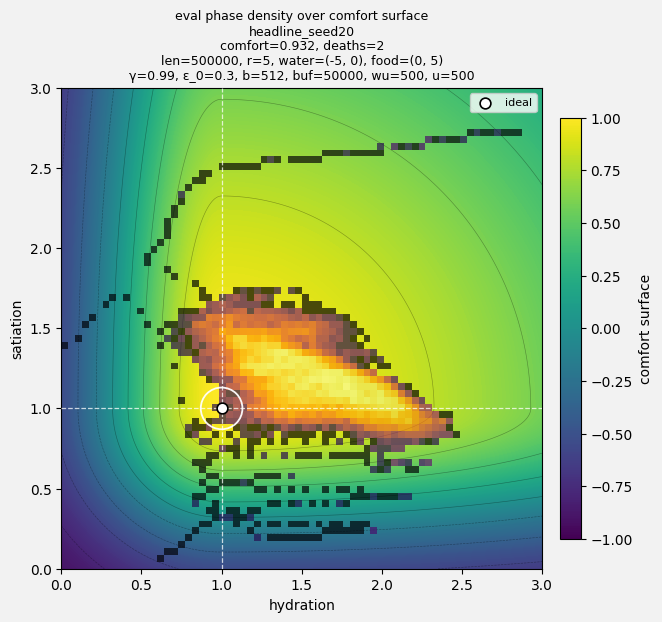

saved: c:\Users\Adarsh Arun\Downloads\homeostatic-agents-main\results\best_figures\hex_occupancy_log_headline_seed20.png


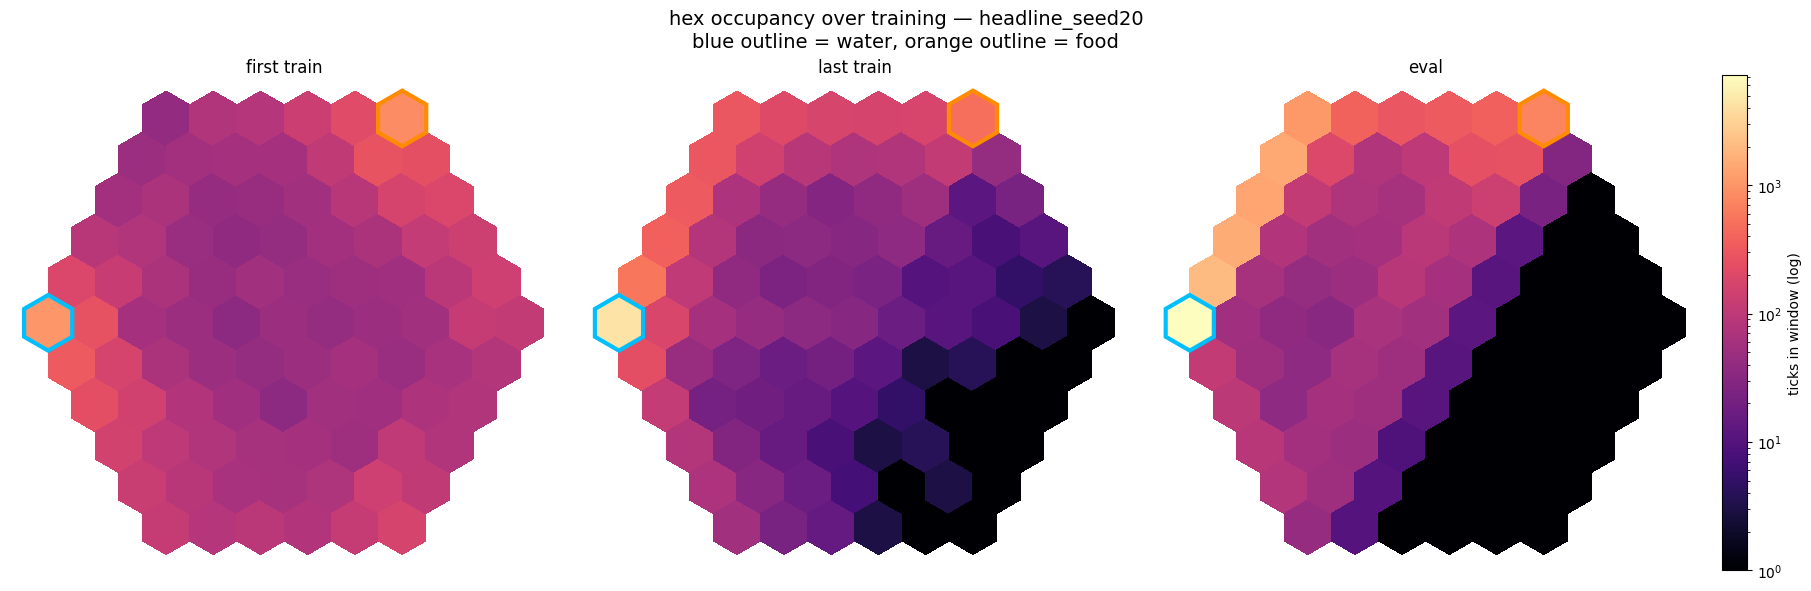

-> results/best_figures/phase_density__headline.png
-> results/best_figures/hex_occupancy__headline.png


In [27]:
# =====================================================================
# FRONT-PAGE FIGURES  →  repo-root  results/best_figures/
# phase density + hex occupancy for the headline seed.
# Run after `from plot_fn_3 import *`. (You'll move the old P2 README
# down into 02's folder; these two live at the repo root for the spine.)
# =====================================================================
import pickle, shutil
from pathlib import Path

EXPERIMENT_NAME = "03b_nstep_robust FINAL_Noisy_novelty_50krbuf_comfortv3_10step"
CONFIG_NAME     = "noisy__buf_50k__beta_0p1__novelty_rewards_T__n_step_10__over_0p02__under_0p5"
SEED            = 20      # 20 = upper-median representative (comfort 0.932, 2 deaths)
                         # 74 = clean showcase (0 deaths, perfectish 1.0)

here    = Path.cwd()
proto   = next((p for p in [here, *here.parents] if p.name == "03b_nstep_robust"), here)
gitroot = next((p for p in [here, *here.parents] if (p / ".git").exists()), here)
sweep   = proto / "results" / "sweeps" / EXPERIMENT_NAME
root_fig = gitroot / "results" / "best_figures"          # <- repo root, where _save_fig writes
root_fig.mkdir(parents=True, exist_ok=True)

# --- load headline seed (re-run if the pkl isn't on disk) ---
pkl = sweep / "runs" / f"{CONFIG_NAME}__seed{SEED}.pkl"
if pkl.exists():
    run = pickle.load(open(pkl, "rb"))
    print(f"loaded {pkl.name} | comfort={run['mean_comfort']:.3f} deaths={run['death_count_eval']}")
else:
    print(f"pkl not found, re-running seed {SEED}...")
    run = sim_instance(
        seed=SEED, model_type="noisy_DQN", beta=0.1, novelty_rewards=True,
        n_step=10, over_w=0.02, under_w=0.5, replay_archive_len=50000,
        sim_len=500_000, eval_len=20_000,
        env_kwargs=dict(radius=5, water_coord=(-5, 0), food_coord=(0, 5)),
    )

# --- render with the existing fns; save=True writes to repo-root best_figures ---
tag = f"headline_seed{SEED}"
plot_phase_heatmap(run, name=tag, save=True)        # -> phase_density_surface_<tag>.png
plot_hex_occupancy_log(run, name=tag, save=True)    # -> hex_occupancy_log_<tag>.png

# --- rename to the fixed names the front-page README points at ---
for src_name, dst_name in [
    (f"phase_density_surface_{tag}.png", "phase_density__headline.png"),
    (f"hex_occupancy_log_{tag}.png",     "hex_occupancy__headline.png"),
]:
    shutil.copyfile(root_fig / src_name, root_fig / dst_name)
    print(f"-> results/best_figures/{dst_name}")

In [24]:
import pandas as pd, numpy as np
from pathlib import Path
from statsmodels.stats.proportion import proportion_confint

base = Path("results/sweeps")
CSV = base / "03b_nstep_robust FINAL_Noisy_novelty_50krbuf_comfortv3_10step" / "runs_df.csv"
df = pd.read_csv(CSV)

pe = pd.to_numeric(df.path_efficiency,      errors="coerce")
pf = pd.to_numeric(df.perfectish_trip_rate, errors="coerce")
dd = pd.to_numeric(df.eval_deaths,          errors="coerce")
fv = pd.to_numeric(df.food_visit_pct,       errors="coerce")
n  = len(df)

cycles = (pe >= 0.9) & (pf > 0)            # clean efficient round trips
print(f"n = {n}")
print(f"cycles cleanly (pre-death-cap): {int(cycles.sum())}/{n}\n")

print("death-cap sensitivity:")
for cap in [0, 5, 10, np.inf]:
    k = int((cycles & (dd <= cap)).sum())
    lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
    tag = "no cap" if cap == np.inf else f"≤{cap:>2.0f}"
    print(f"  deaths {tag:>6}:  {k:3d}/{n} = {k/n:5.1%}  95% Wilson [{lo:.1%}, {hi:.1%}]")

DEATH_CAP = 5
solved = cycles & (dd <= DEATH_CAP)
k = int(solved.sum()); lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
print(f"\nHEADLINE (path_eff≥0.9 ∧ perfectish>0 ∧ deaths≤{DEATH_CAP})")
print(f"  {k}/{n} = {k/n:.1%}   95% Wilson [{lo:.1%}, {hi:.1%}]\n")

# failure-mode split over the UNSOLVED seeds (mutually exclusive, ordered)
unsolved   = ~solved
campers    = unsolved & (fv < 1.0)                          # water-cult: barely reaches food
bled       = unsolved & ~campers & cycles & (dd > DEATH_CAP)  # cycles clean but dies too much
messy      = unsolved & ~campers & ~bled                    # reaches food but inefficient/incomplete
print("failure modes among unsolved:")
print(f"  water-cult campers (food%<1):      {int(campers.sum())}")
print(f"  cycles cleanly but bled out:       {int(bled.sum())}")
print(f"  reaches food, messy/inefficient:   {int(messy.sum())}")
assert int(campers.sum()+bled.sum()+messy.sum()) == int(unsolved.sum())

s = df[solved]
print("\nmedians among solved seeds:")
for col, lab in [("eval_deaths","deaths"),("mean_comfort","comfort"),
                 ("path_efficiency","path_eff"),("perfectish_trip_rate","perfectish"),
                 ("trip_success_rate","trip_success"),("food_visit_pct","food%")]:
    print(f"  {lab:13s} {pd.to_numeric(s[col]).median():.3f}")

n = 100
cycles cleanly (pre-death-cap): 52/100

death-cap sensitivity:
  deaths    ≤ 0:   26/100 = 26.0%  95% Wilson [18.4%, 35.4%]
  deaths    ≤ 5:   38/100 = 38.0%  95% Wilson [29.1%, 47.8%]
  deaths    ≤10:   42/100 = 42.0%  95% Wilson [32.8%, 51.8%]
  deaths no cap:   52/100 = 52.0%  95% Wilson [42.3%, 61.5%]

HEADLINE (path_eff≥0.9 ∧ perfectish>0 ∧ deaths≤5)
  38/100 = 38.0%   95% Wilson [29.1%, 47.8%]

failure modes among unsolved:
  water-cult campers (food%<1):      16
  cycles cleanly but bled out:       11
  reaches food, messy/inefficient:   35

medians among solved seeds:
  deaths        0.000
  comfort       0.932
  path_eff      1.000
  perfectish    0.935
  trip_success  0.179
  food%         4.547


available configs:
0: novelty_rewards_F__noisy | n=5 | median comfort=0.847 | median-run deaths=1
1: novelty_rewards_F__vanilla | n=5 | median comfort=0.780 | median-run deaths=82
2: novelty_rewards_T__noisy | n=5 | median comfort=0.881 | median-run deaths=12
3: novelty_rewards_T__vanilla | n=5 | median comfort=0.480 | median-run deaths=94
no sigma_w_mean logged in selected configs (noisy_DQN only)


C:\Users\Adarsh Arun\AppData\Local\Temp\ipykernel_6916\319875653.py:141: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Adarsh Arun\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


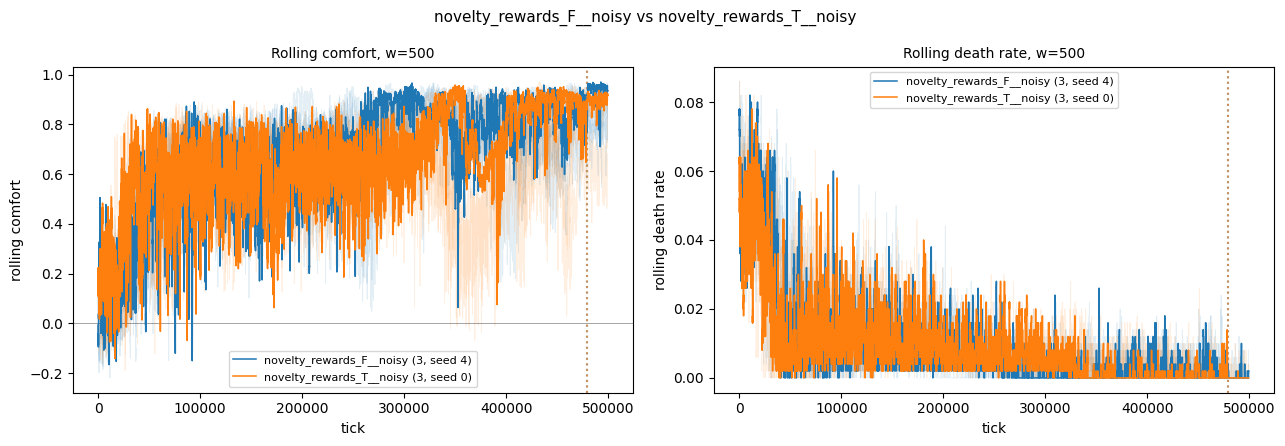

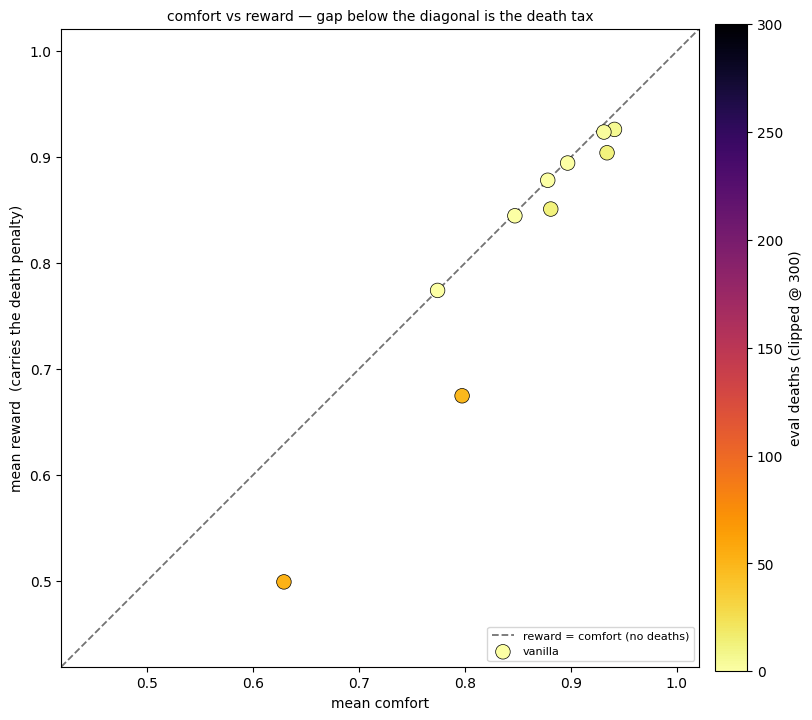

C:\Users\Adarsh Arun\AppData\Local\Temp\ipykernel_6916\319875653.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


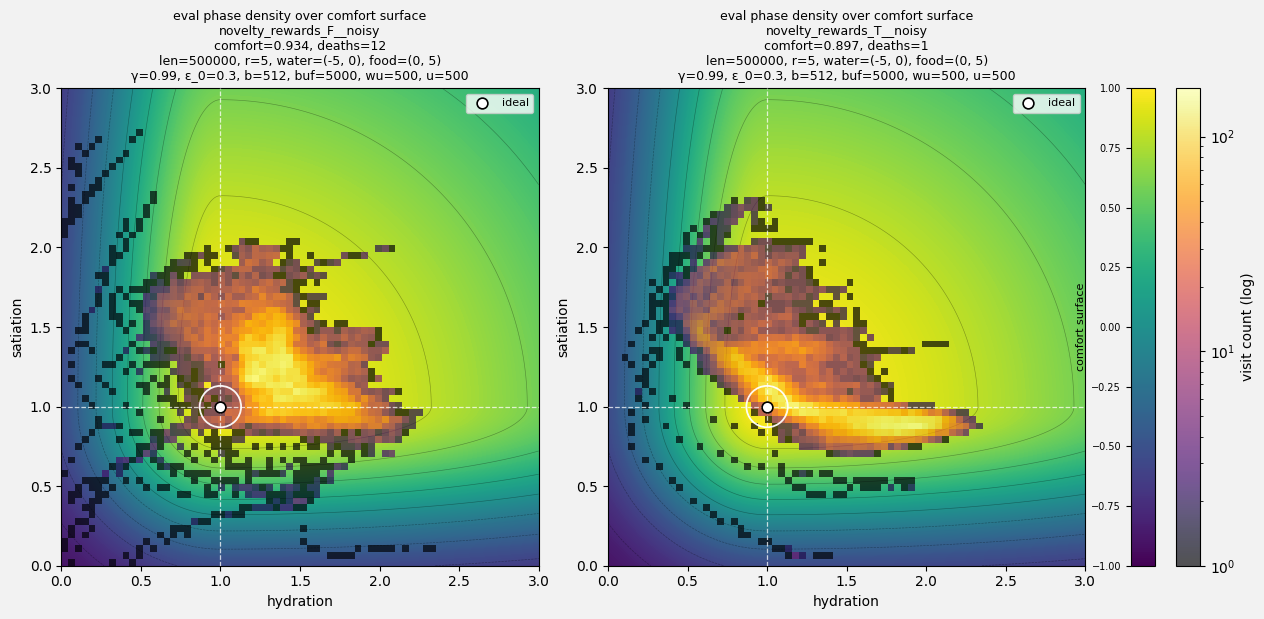

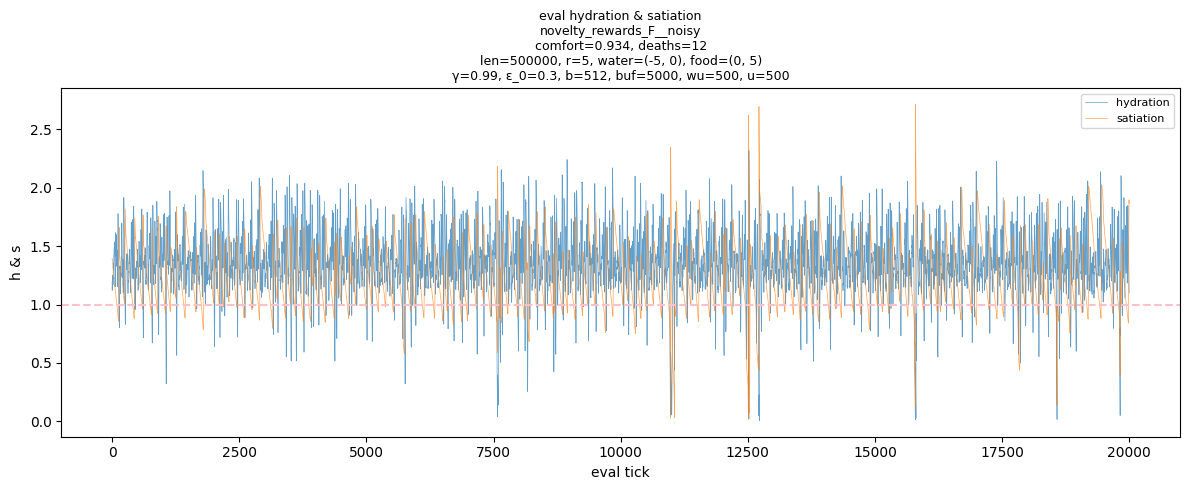

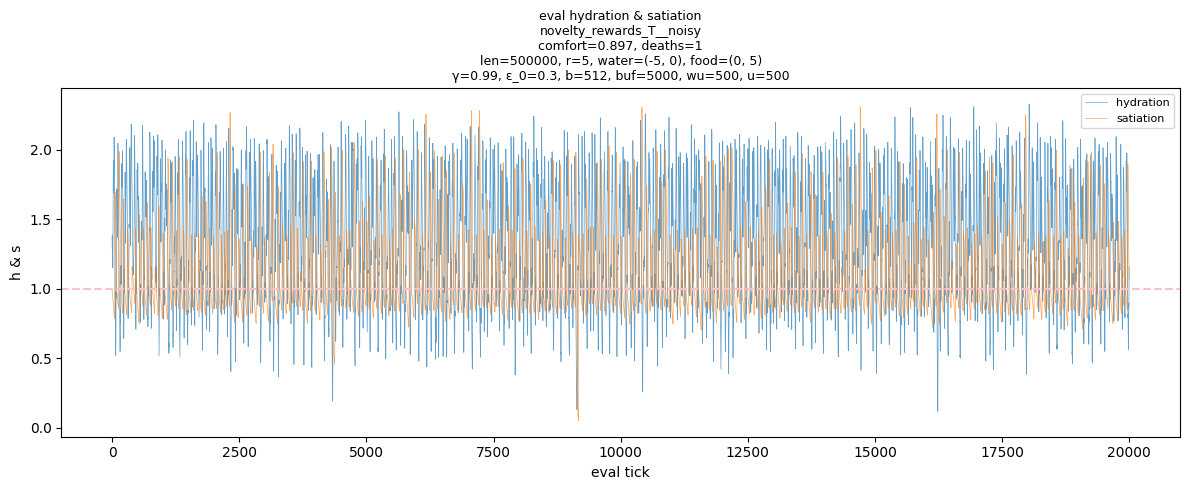

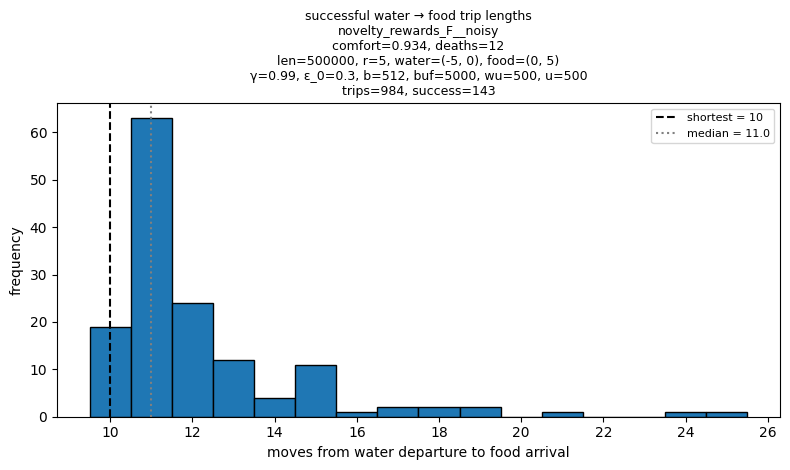

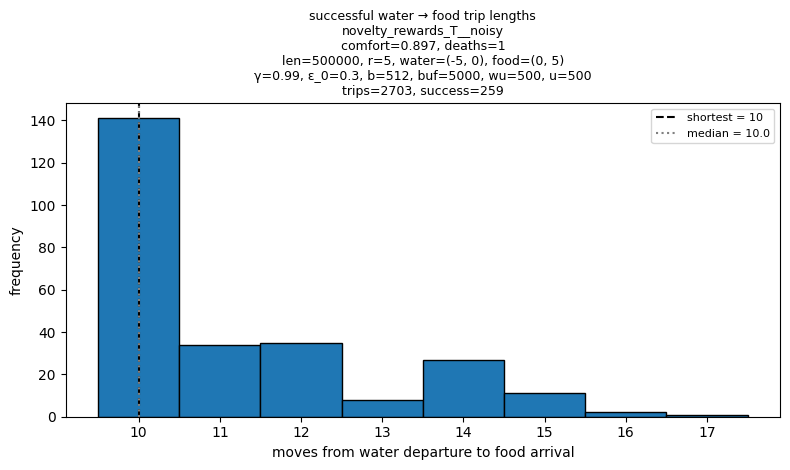

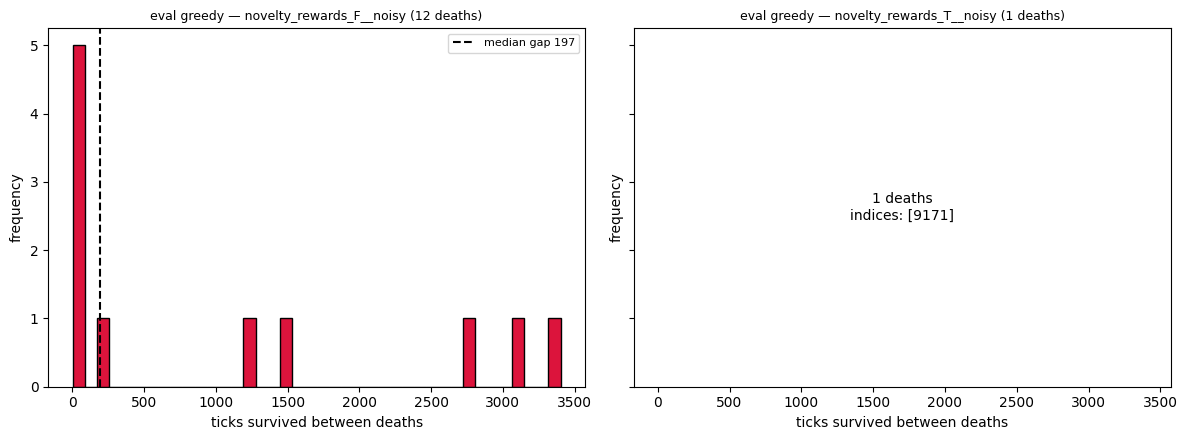

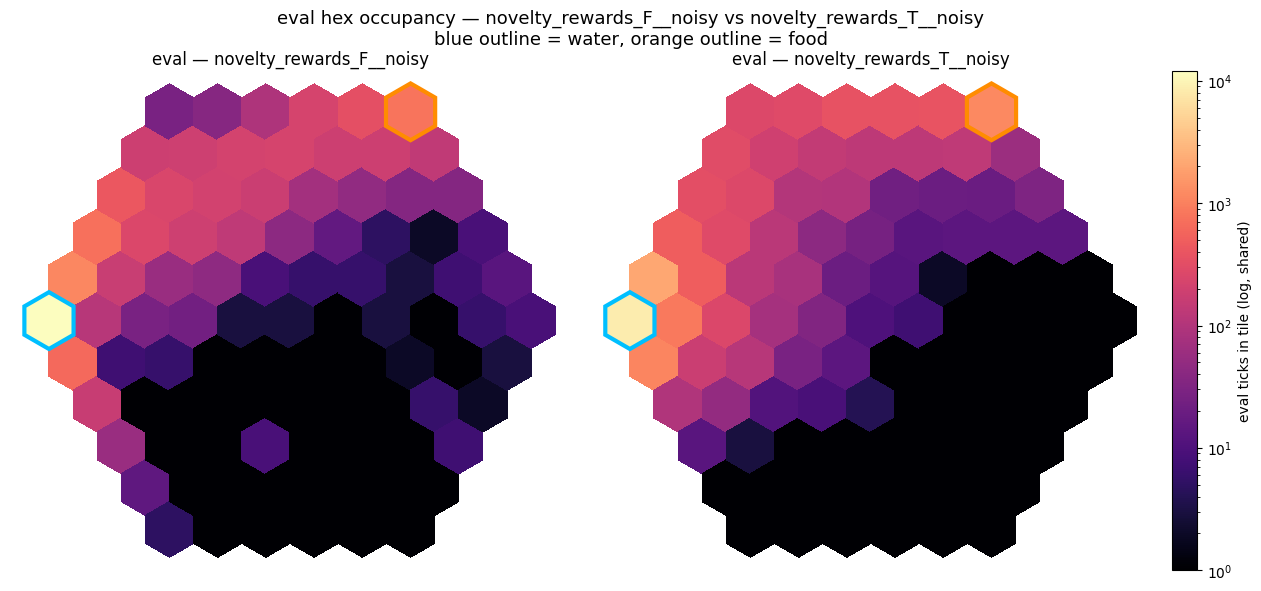

In [ ]:
#region PLOT COMPARISON

def print_available_configs():
    print("available configs:")

    for i, name in enumerate(res.keys()):
        ranked = res[name]["ranked"]
        median = res[name]["median"]

        print(
            f"{i}: {name} | "
            f"n={len(ranked)} | "
            f"median comfort={median['mean_comfort']:.3f} | "
            f"median-run deaths={median['death_count_eval']}"
        )

def choose_configs():
    names = list(res.keys())

    print_available_configs()
    sel = input("Select runs, comma-separated e.g. 0,1: ")

    idxs = [int(x.strip()) for x in sel.split(",") if x.strip() != ""]

    if len(idxs) < 1:
        raise ValueError("Select at least one config.")

    for i in idxs:
        if i < 0 or i >= len(names):
            raise IndexError(f"Config index out of range: {i}")

    return [names[i] for i in idxs]


NAMES = choose_configs()
PICK = 3


plot_sigma_decay_compare(NAMES, res_obj=res)

def rolling_mean(x, window):
    x = np.asarray(x, dtype=float)

    if window <= 0:
        raise ValueError("window must be positive")

    if len(x) < window:
        return np.array([])

    c = np.cumsum(np.insert(x, 0, 0.0))
    return (c[window:] - c[:-window]) / window


def draw_rolling(ax, series, key, window, ymarks=()):
    # background seed haze
    for s in series:
        for run in s["bg"]:
            ax.plot(
                rolling_mean(run[key], window),
                color=s["haze"],
                lw=0.6,
                alpha=0.12,
                zorder=1,
            )

    # selected representative run
    for s in series:
        run = s["run"]
        ax.plot(
            rolling_mean(run[key], window),
            color=s["color"],
            lw=1.1,
            zorder=3,
            label=s["label"],
        )

        eb_roll = max(0, eb_of(run) - window + 1)
        ax.axvline(
            eb_roll,
            ls=":",
            c=s["color"],
            alpha=0.6,
            zorder=2,
        )

    for y in ymarks:
        ax.axhline(y, ls="-", c="black", lw=0.5, alpha=0.5)

    ax.legend(fontsize=8)



def safe_fig_name(prefix, names):
    joined = "_vs_".join(names)
    joined = joined.replace(" ", "_").replace("/", "-").replace("//", "-")
    return f"{prefix}_{joined}"


def build_comparison_series(names, pick, colors):
    picked = [(name, pick_run(name, pick=pick, res_obj=res)) for name in names]

    series = []
    for i, (name, run) in enumerate(picked):
        color = colors[i % len(colors)]
        haze = color if len(picked) > 1 else "gray"

        series.append({
            "bg": res[name]["ranked"],
            "run": run,
            "color": color,
            "haze": haze,
            "label": f"{name} ({pick}, seed {run['seed']})",
        })

    return picked, series


def plot_comparison(
    names,
    pick="median",
    window=500,
    save=False,
    colors=("tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"),
):
    picked, series = build_comparison_series(names, pick, colors)

    # rolling comfort + death rate
    fig, (ax_c, ax_d) = plt.subplots(1, 2, figsize=(13, 4.5))

    draw_rolling(ax_c, series, "comfort_T", window, ymarks=(0,))
    ax_c.set_title(f"Rolling comfort, w={window}", fontsize=10)
    ax_c.set_xlabel("tick")
    ax_c.set_ylabel("rolling comfort")

    draw_rolling(ax_d, series, "death_T", window)
    ax_d.set_title(f"Rolling death rate, w={window}", fontsize=10)
    ax_d.set_xlabel("tick")
    ax_d.set_ylabel("rolling death rate")

    fig.suptitle(" vs ".join(names), fontsize=11)
    plt.tight_layout()

    plot_comfort_vs_reward(NAMES, res_obj=res)       # or just your selected ones

    if save:
        _save_fig(fig, safe_fig_name("cmp_rolling", names))

    plt.show()

    # phase density
    from matplotlib.gridspec import GridSpec

    n = len(picked)
    fig = plt.figure(figsize=(6.8 * n + 1.4, 6.2))
    gs  = GridSpec(1, n + 2,
                width_ratios=[*([1] * n), 0.045, 0.045],
                wspace=0.08, figure=fig)

    plot_axes  = [fig.add_subplot(gs[0, i]) for i in range(n)]
    cax_surf   = fig.add_subplot(gs[0, n])
    cax_dens   = fig.add_subplot(gs[0, n + 1])

    surf_m = dens_m = None
    for (name, run), ax in zip(picked, plot_axes):
        s, d = plot_phase_heatmap(run, name=name, ax=ax)
        surf_m = surf_m or s
        dens_m = dens_m or d          # first non-None density scale wins

    cbar_s = fig.colorbar(surf_m, cax=cax_surf)
    cbar_s.ax.yaxis.set_ticks_position('left')
    cbar_s.ax.yaxis.set_label_position('left')
    cbar_s.set_label("comfort surface", fontsize=8)
    cbar_s.set_ticks(np.linspace(-1, 1, 9))
    cbar_s.ax.tick_params(labelsize=7)

    if dens_m is not None:
        cbar_d = fig.colorbar(dens_m, cax=cax_dens)
        cbar_d.set_label("visit count (log)")

    plt.tight_layout()
    plt.show()

    # per-run diagnostics
    for name, run in picked:
        plot_eval_hs(run, name=name, save=save)

    for name, run in picked:
        plot_trip_lengths(run, name=name, save=save)

    # comparison diagnostics
    plot_death_gaps_eval_compare(picked, save=save)
    plot_hex_eval_compare(picked, save=save)


plot_comparison(NAMES, pick=PICK, window=500)

#endregion

In [ ]:
#region SUMMARY BLOCK

def fmt_pct(x, digits=1):
    if pd.isna(x):
        return "nan"
    return f"{100*x:.{digits}f}%"

def fmt_runtime(x):
    if pd.isna(x):
        return "nan"
    if "fmt_time" in globals():
        return fmt_time(x)
    return f"{x:.1f}s"

def fmt_num(x, digits=3):
    if pd.isna(x):
        return "nan"
    return f"{x:.{digits}f}"


def print_final_sweep_summary(summary_df, runs_df, experiment_name, PROTOTYPE_NAME):
    if summary_df.empty:
        print("No summary data loaded.")
        return

    print("=" * 90)
    print(f"FINAL SWEEP SUMMARY: {experiment_name}")
    print("=" * 90)

    print("/nConfigs tested:")
    print(f"  configs: {summary_df['config'].nunique()}")
    print(f"  total runs: {len(runs_df)}")
    print(f"  seeds per config: {int(summary_df['n_seeds'].median())}")

    print("/nCompact summary table:")
    cols = [
        "config",
        "n_seeds",
        "sim_len",
        "run_time_seconds_median",
        #"seconds_per_100k_ticks_median",
        #"ticks_per_second_median",
        "mean_comfort_median",
        "mean_comfort_std",
        "eval_deaths_median",
        "zero_death_rate",
        "food_visit_pct_median",
        "water_visit_pct_median",
        "path_efficiency_median",
        "perfectish_trip_rate_median",
        "solved_rate",
    ]

    table = summary_df[cols].copy()

    table["mean_comfort_median"] = table["mean_comfort_median"].map(lambda x: round(x, 3))
    table["mean_comfort_std"] = table["mean_comfort_std"].map(lambda x: round(x, 3) if not pd.isna(x) else np.nan)
    table["eval_deaths_median"] = table["eval_deaths_median"].map(lambda x: round(x, 1))
    table["zero_death_rate"] = table["zero_death_rate"].map(lambda x: f"{100*x:.0f}%")
    table["food_visit_pct_median"] = table["food_visit_pct_median"].map(lambda x: round(x, 1))
    table["water_visit_pct_median"] = table["water_visit_pct_median"].map(lambda x: round(x, 1))
    table["path_efficiency_median"] = table["path_efficiency_median"].map(lambda x: round(x, 3) if not pd.isna(x) else np.nan)
    table["perfectish_trip_rate_median"] = table["perfectish_trip_rate_median"].map(lambda x: f"{100*x:.0f}%" if not pd.isna(x) else "nan")
    table["solved_rate"] = table["solved_rate"].map(lambda x: f"{100*x:.0f}%")
    table["run_time_seconds_median"] = table["run_time_seconds_median"].map(fmt_runtime)
    #table["seconds_per_100k_ticks_median"] = table["seconds_per_100k_ticks_median"].map(lambda x: round(x, 2) if not pd.isna(x) else np.nan)
    #table["ticks_per_second_median"] = table["ticks_per_second_median"].map(lambda x: round(x, 1) if not pd.isna(x) else np.nan)

    print(table.to_string(index=False))

    print("/n" + "-" * 90)
    print("Winners / notable configs")
    print("-" * 90)

    best_comfort = summary_df.sort_values(
        ["mean_comfort_median", "mean_comfort_std"],
        ascending=[False, True],
    ).iloc[0]

    best_stability = summary_df.sort_values(
        ["mean_comfort_std", "mean_comfort_median"],
        ascending=[True, False],
    ).iloc[0]

    best_deaths = summary_df.sort_values(
        ["zero_death_rate", "eval_deaths_median", "mean_comfort_median"],
        ascending=[False, True, False],
    ).iloc[0]

    best_path = summary_df.sort_values(
        ["path_efficiency_median", "perfectish_trip_rate_median", "mean_comfort_median"],
        ascending=[False, False, False],
    ).iloc[0]

    best_solved = summary_df.sort_values(
        ["solved_rate", "mean_comfort_median", "path_efficiency_median"],
        ascending=[False, False, False],
    ).iloc[0]

    #best_runtime_efficiency = summary_df.sort_values(
    #["seconds_per_100k_ticks_median", "mean_comfort_median"],
    #ascending=[True, False],
    #).iloc[0]

    print(f"/nBest median comfort:")
    print(f"  {best_comfort['config']}")
    print(f"  median comfort = {best_comfort['mean_comfort_median']:.3f}")
    print(f"  std comfort    = {best_comfort['mean_comfort_std']:.3f}")

    print(f"/nMost stable comfort:")
    print(f"  {best_stability['config']}")
    print(f"  std comfort    = {best_stability['mean_comfort_std']:.3f}")
    print(f"  median comfort = {best_stability['mean_comfort_median']:.3f}")

    print(f"/nBest death robustness:")
    print(f"  {best_deaths['config']}")
    print(f"  zero-death rate     = {100*best_deaths['zero_death_rate']:.0f}%")
    print(f"  median eval deaths  = {best_deaths['eval_deaths_median']:.1f}")

    print(f"/nBest path efficiency:")
    print(f"  {best_path['config']}")
    print(f"  path efficiency        = {best_path['path_efficiency_median']:.3f}")
    print(f"  perfect-ish trip rate  = {100*best_path['perfectish_trip_rate_median']:.0f}%")

    print(f"/nBest overall solved rate:")
    print(f"  {best_solved['config']}")
    print(f"  solved rate      = {100*best_solved['solved_rate']:.0f}%")
    print(f"  median comfort   = {best_solved['mean_comfort_median']:.3f}")
    print(f"  path efficiency  = {best_solved['path_efficiency_median']:.3f}")
    print(f"/nBest runtime efficiency:")
    #print(f"  {best_runtime_efficiency['config']}")
    #print(f"  seconds per 100k      = {best_runtime_efficiency['seconds_per_100k_ticks_median']:.2f}")
    #print(f"  median comfort        = {best_runtime_efficiency['mean_comfort_median']:.3f}")

    print("/n" + "-" * 90)

    print("/nSaved files:")
    out = sweep_dir(experiment_name, PROTOTYPE_NAME=PROTOTYPE_NAME)
    print(f"  runs CSV:    {out / 'runs_df.csv'}")
    print(f"  summary CSV: {out / 'summary_df.csv'}")


print_final_sweep_summary(summary_df, runs_df, EXPERIMENT_NAME, PROTOTYPE_NAME=PROTOTYPE_NAME)

#endregion

FINAL SWEEP SUMMARY: 03b_nstep_robust novelty_rewards_p05__Vanilla_vs_Noisy

Configs tested:
  configs: 4
  total runs: 20
  seeds per config: 5

Compact summary table:
                    config  n_seeds  sim_len run_time_seconds_median  mean_comfort_median  mean_comfort_std  eval_deaths_median zero_death_rate  food_visit_pct_median  water_visit_pct_median  path_efficiency_median perfectish_trip_rate_median solved_rate
novelty_rewards_F__vanilla        5   500000                  2m 55s                0.780             0.139                 6.0             40%                    2.5                    48.3                   0.909                         74%         40%
  novelty_rewards_T__noisy        5   500000                   3m 8s                0.881             0.121                 3.0             20%                    4.7                    48.8                   1.000                         92%         20%
  novelty_rewards_F__noisy        5   500000                  3m 1

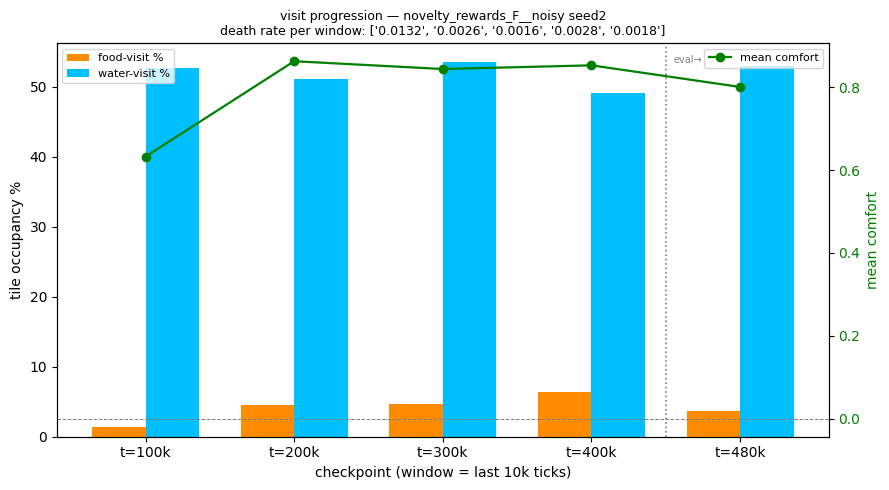

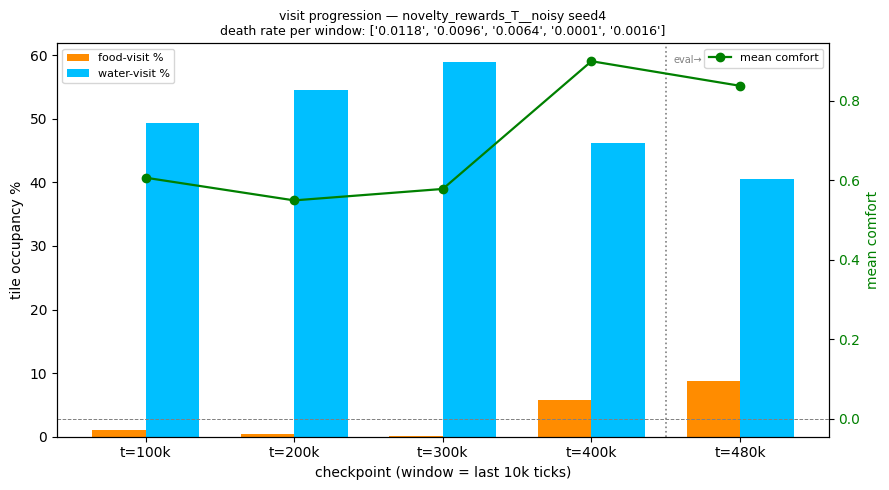

In [ ]:
#region FOOD/WATER VISIT PROGRESSION

CHECKPOINTS = [100_000, 200_000, 300_000, 400_000, 480_000]
WINDOW = 10_000

def _occ_pct(coords, target):
    if len(coords) == 0: return np.nan
    on = (coords[:, 0] == target[0]) & (coords[:, 1] == target[1])
    return 100.0 * on.mean()

def plot_visit_progression(run, name="run", checkpoints=CHECKPOINTS, window=WINDOW, save=False):
    coords  = np.asarray(run["coordinates_T"], dtype=int)
    comfort = np.asarray(run["comfort_T"], dtype=float)
    death   = np.asarray(run["death_T"], dtype=float)
    eb      = eb_of(run)
    _, water_coord, food_coord = get_run_env(run)

    food_occ, water_occ, mean_c, death_r = [], [], [], []

    for ck in checkpoints:
        s = max(0, ck - window)
        e = min(ck, len(coords))
        chunk = coords[s:e]
        food_occ.append(_occ_pct(chunk, food_coord))
        water_occ.append(_occ_pct(chunk, water_coord))
        mean_c.append(comfort[s:e].mean() if e > s else np.nan)
        death_r.append(death[s:e].mean() if e > s else np.nan)

    x      = np.arange(len(checkpoints))
    labels = [f"t={ck//1000}k" for ck in checkpoints]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - 0.18, food_occ,  width=0.36, color="darkorange",  label="food-visit %")
    ax.bar(x + 0.18, water_occ, width=0.36, color="deepskyblue", label="water-visit %")
    ax.set_ylabel("tile occupancy %")
    ax.set_xlabel(f"checkpoint (window = last {window//1000}k ticks)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend(loc="upper left", fontsize=8)

    for ck_i, ck in enumerate(checkpoints):
        if ck >= eb:
            ax.axvline(ck_i - 0.5, ls=":", c="gray", lw=1.2)
            ax.text(ck_i - 0.45, ax.get_ylim()[1] * 0.97, "eval→", fontsize=7, color="gray", va="top")
            break

    axc = ax.twinx()
    axc.plot(x, mean_c, "-o", color="green", lw=1.6, label="mean comfort")
    axc.axhline(0, ls="--", c="gray", lw=0.7)
    axc.set_ylabel("mean comfort", color="green")
    axc.tick_params(axis="y", labelcolor="green")
    axc.legend(loc="upper right", fontsize=8)

    ax.set_title(
        f"visit progression — {name}/n"
        f"death rate per window: {['%.4f' % d for d in death_r]}",
        fontsize=9
    )
    plt.tight_layout()
    if save: _save_fig(fig, f"visit_progression_{name}")
    plt.show()


for config_name in NAMES:
    run = res[config_name]["median"]
    plot_visit_progression(run, name=f"{config_name} seed{run['seed']}")

#endregion

In [1]:
out = sim_instance(seed=1, model_type="noisy_DQN", sigma_0=0.5, sim_len=500000,
                   env_kwargs={"radius":5,"water_coord":(-5,0),"food_coord":(0,5)})
print(len(out["sigma_w_mean"]))   # now should be ~24000

NameError: name 'sim_instance' is not defined

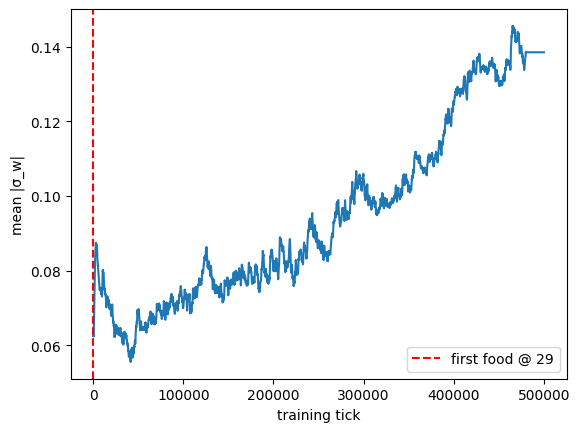

first food tick: 29 | sigma there: 0.0625


In [14]:
import numpy as np, matplotlib.pyplot as plt
sig = np.array(out["sigma_w_mean"])
coords = out["coordinates_T"][:480000]
food_hits = np.flatnonzero((coords[:,0]==0) & (coords[:,1]==5))
ff = food_hits[0] if len(food_hits) else None

plt.plot(np.arange(len(sig))*20, sig)
if ff is not None:
    plt.axvline(ff, color="red", ls="--", label=f"first food @ {ff}")
plt.xlabel("training tick"); plt.ylabel("mean |σ_w|"); plt.legend(); plt.show()
print("first food tick:", ff, "| sigma there:", sig[min(len(sig)-1, ff//20)] if ff else "never")